# **Fase III - Variational Autoencoder (β-VAE)**

---

- Representacion latente no-lineal de 500k prestamos hipotecarios (Subset B)
- Entrenamiento de un MLP β-VAE con entity embeddings y KL ciclico
- Grid search sobre la dimension latente z para seleccionar el mejor modelo
- Proyeccion de embeddings para clustering downstream (Fase IV)

In [ ]:
import os, sys, warnings, time, pickle, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import QuantileTransformer, LabelEncoder, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/Semestre 7/Analítica/proyecto-1')
else:
    BASE_DIR = Path('.')

DATA_DIR = BASE_DIR / 'data'
CHECKPOINT_DIR = BASE_DIR / 'checkpoints' / 'vae'
RESULTS_DIR = BASE_DIR / 'results' / 'vae'
for d in [DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 777

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")
print(f"Python: {sys.version.split()[0]}")
print(f"Base dir: {BASE_DIR}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
Python: 3.12.12
Base dir: /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1
Timestamp: 2026-02-23 02:21


## **Carga de datos y EDA rapido**

Subset B (500k loans, 51 cols) es el set de entrenamiento del VAE.
Subset A (50k loans, 41 cols) se proyecta despues para clustering.

In [ ]:
subset_b_path = DATA_DIR / 'subset_b'
df_b = pd.read_parquet(subset_b_path)
print(f"Subset B: {df_b.shape[0]:,} loans x {df_b.shape[1]} columnas")

subset_a_dir = DATA_DIR / 'subset_a'
csv_files = sorted(subset_a_dir.glob('*.csv'))
df_a = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f"Subset A: {df_a.shape[0]:,} loans x {df_a.shape[1]} columnas")

print(f"\nTipos de datos (Subset B):")
print(df_b.dtypes.value_counts())

null_pct = (df_b.isnull().sum() / len(df_b) * 100).sort_values(ascending=False)
print(f"\nNulls por columna (top 15):")
print(null_pct[null_pct > 0].head(15).to_string())

print(f"\nDistribucion de stratum:")
print(df_b['stratum'].value_counts())

key_vars = ['borrower_credit_score', 'orig_ltv', 'dti', 'orig_upb',
            'orig_interest_rate', 'max_delinquency_status']
print(f"\nEstadisticas de variables clave:")
print(df_b[key_vars].describe().T.to_string())

Subset B: 498,542 loans x 51 columnas
Subset A: 49,735 loans x 41 columnas

Tipos de datos (Subset B):
float64    21
int32      14
object     13
int64       3
Name: count, dtype: int64

Nulls por columna (top 15):
time_to_default              100.000000
net_severity                  89.933245
net_loss                      89.933245
mi_type                       76.155068
mi_percentage                 76.155068
co_borrower_credit_score      56.446197
ph_months_current_24          54.057431
ph_months_delinquent_24       54.057431
ph_max_delinquency_24         54.057431
ph_recent_delinquency_3m      54.057431
time_to_first_delinquency     50.032896
final_zero_balance_code       26.544604
last_active_upb                1.873062
dti                            1.716204
borrower_credit_score          0.372486

Distribucion de stratum:
stratum
performing     249307
serious_dlq     99914
early_dlq       99134
default         50187
Name: count, dtype: int64

Estadisticas de variables clave:
    

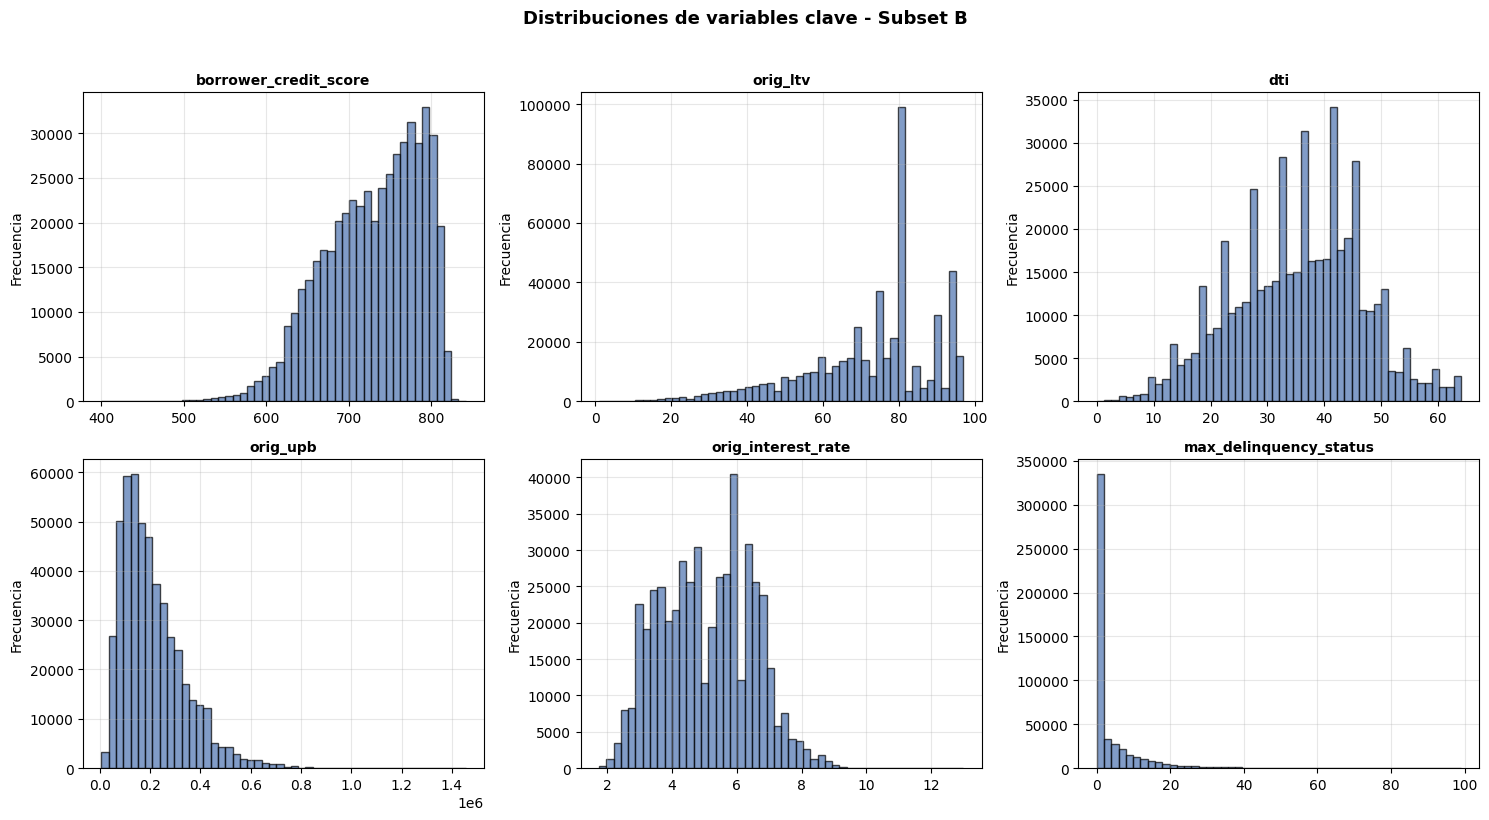

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, key_vars):
    df_b[col].dropna().hist(ax=ax, bins=50, edgecolor='black', alpha=0.7,
                            color='#4C72B0')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.grid(True, alpha=0.3)
fig.suptitle('Distribuciones de variables clave - Subset B', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_distribucion_variables_clave.png', dpi=150,
            bbox_inches='tight')
plt.show()

## **Preprocesamiento hibrido**

Cada subtipo de variable recibe una transformacion distinta segun su
distribucion: GMM para bimodales, `log1p` para colas pesadas,
codificacion 2-partes para zero-inflated, y `QuantileTransformer` para
el resto.

### **Clasificacion de columnas**

In [ ]:
METADATA_COLS = ['loan_id', 'acquisition_quarter', 'origination_year',
                 'property_state', 'stratum', 'lph_available']
TARGET_COLS = ['is_default', 'net_loss', 'net_severity', 'ever_d90',
               'ever_d180', 'ever_foreclosed', 'final_zero_balance_code',
               'is_clean_liquidation', 'time_to_default']
FINANCIAL_DERIVED = ['rate_spread', 'upb_paydown_pct', 'last_active_upb']

BIMODAL_COLS = ['orig_interest_rate', 'upb_paydown_pct']
HEAVY_TAIL_COLS = ['orig_upb', 'dti']
ZERO_INFLATED_COLS = ['max_delinquency_status', 'mi_percentage']
STANDARD_CONT_COLS = [
    'borrower_credit_score', 'co_borrower_credit_score',
    'orig_ltv', 'orig_cltv', 'orig_loan_term',
    'months_delinquent_30plus', 'months_delinquent_60plus',
    'months_delinquent_90plus', 'loan_duration_months',
    'time_to_first_delinquency',
    'ph_months_current_24', 'ph_months_delinquent_24',
    'ph_max_delinquency_24',
    'rate_spread', 'last_active_upb',
]

ALL_CONTINUOUS = (BIMODAL_COLS + HEAVY_TAIL_COLS
                  + ZERO_INFLATED_COLS + STANDARD_CONT_COLS)

CATEGORICAL_COLS = ['channel', 'loan_purpose', 'property_type',
                    'occupancy_status', 'vintage_bin', 'mi_type', 'num_units']
CAT_CARDINALITIES = {}

BINARY_COLS = ['first_time_buyer', 'has_coborrower',
               'high_balance_loan_indicator', 'ever_modified',
               'had_forbearance', 'had_servicing_transfer',
               'lph_available', 'ph_recent_delinquency_3m']

MISSING_FLAG_COLS = ['co_borrower_fico_missing']

print(f"Continuas: {len(ALL_CONTINUOUS)} (bimodal={len(BIMODAL_COLS)}, "
      f"heavy_tail={len(HEAVY_TAIL_COLS)}, zero_inflated={len(ZERO_INFLATED_COLS)}, "
      f"standard={len(STANDARD_CONT_COLS)})")
print(f"Categoricas: {len(CATEGORICAL_COLS)}")
print(f"Binarias: {len(BINARY_COLS)}")
print(f"Metadata (no VAE): {len(METADATA_COLS)}")
print(f"Target (no VAE): {len(TARGET_COLS)}")

Continuas: 21 (bimodal=2, heavy_tail=2, zero_inflated=2, standard=15)
Categoricas: 7
Binarias: 8
Metadata (no VAE): 6
Target (no VAE): 9


### **Imputacion y encoding**

`co_borrower_credit_score` se imputa con la mediana de los loans que
si tienen co-borrower. `time_to_first_delinquency` NULL significa que
nunca hubo delinquency, se imputa con `loan_duration_months`.

In [ ]:
df = df_b.copy()

df['co_borrower_fico_missing'] = df['co_borrower_credit_score'].isnull().astype(int)

# mediana solo de loans con co-borrower
co_median = df.loc[df['co_borrower_credit_score'].notna(),
                   'co_borrower_credit_score'].median()
df['co_borrower_credit_score'] = df['co_borrower_credit_score'].fillna(co_median)

# NULL = nunca DLQ
df['time_to_first_delinquency'] = df['time_to_first_delinquency'].fillna(
    df['loan_duration_months']
)

# LPH: NULL -> 0 (el flag lph_available ya indica disponibilidad)
lph_cols = ['ph_months_current_24', 'ph_months_delinquent_24',
            'ph_max_delinquency_24', 'ph_recent_delinquency_3m']
for col in lph_cols:
    df[col] = df[col].fillna(0)

# resto de continuas: mediana
for col in ALL_CONTINUOUS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

binary_string_map = {
    'first_time_buyer': {'Y': 1, 'N': 0},
    'high_balance_loan_indicator': {'Y': 1, 'N': 0},
}
for col, mapping in binary_string_map.items():
    if df[col].dtype == object:
        df[col] = df[col].map(mapping).fillna(0).astype(int)

for col in BINARY_COLS:
    df[col] = df[col].fillna(0).astype(int)

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].fillna('MISSING').astype(str))
    label_encoders[col] = le
    CAT_CARDINALITIES[col] = len(le.classes_)

print("Cardinalidades de categoricas:")
for col, card in CAT_CARDINALITIES.items():
    emb_dim = min(50, (card + 1) // 2)
    print(f"  {col}: {card} categorias -> embedding dim {emb_dim}")

vae_cols = (ALL_CONTINUOUS + [c + '_enc' for c in CATEGORICAL_COLS]
            + BINARY_COLS + MISSING_FLAG_COLS)
null_check = df[vae_cols].isnull().sum()
assert null_check.sum() == 0, f"Nulls remanentes:\n{null_check[null_check > 0]}"
print(f"\n0 nulls en {len(vae_cols)} columnas VAE")

Cardinalidades de categoricas:
  channel: 3 categorias -> embedding dim 2
  loan_purpose: 4 categorias -> embedding dim 2
  property_type: 5 categorias -> embedding dim 3
  occupancy_status: 3 categorias -> embedding dim 2
  vintage_bin: 4 categorias -> embedding dim 2
  mi_type: 4 categorias -> embedding dim 2
  num_units: 4 categorias -> embedding dim 2

0 nulls en 37 columnas VAE


### **Split y transformaciones por subtipo**

Split 80/20 estratificado por `stratum`. Los transformers se fitean
solo en train para evitar data leakage.

In [ ]:
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED,
    stratify=df['stratum']
)
print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,}")

# bimodales: GMM(2) within-mode normalization
gmm_transformers = {}
for col in BIMODAL_COLS:
    train_vals = df.iloc[train_idx][col].values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=SEED)
    gmm.fit(train_vals)
    gmm_transformers[col] = gmm

    all_vals = df[col].values.reshape(-1, 1)
    components = gmm.predict(all_vals)
    normalized = np.zeros_like(all_vals, dtype=np.float32).flatten()
    for comp in range(2):
        mask = components == comp
        if mask.sum() > 0:
            mu_c = gmm.means_[comp, 0]
            std_c = np.sqrt(gmm.covariances_[comp, 0, 0])
            normalized[mask] = (all_vals[mask, 0] - mu_c) / (std_c + 1e-8)
    df[col + '_norm'] = normalized

print(f"Bimodales normalizadas: {BIMODAL_COLS}")

# colas pesadas: log1p + StandardScaler
heavy_scalers = {}
for col in HEAVY_TAIL_COLS:
    df[col + '_log'] = np.log1p(df[col].clip(lower=0))
    scaler = StandardScaler()
    scaler.fit(df.iloc[train_idx][[col + '_log']])
    df[col + '_norm'] = scaler.transform(df[[col + '_log']]).flatten()
    heavy_scalers[col] = scaler
    df.drop(columns=[col + '_log'], inplace=True)

print(f"Colas pesadas normalizadas: {HEAVY_TAIL_COLS}")

# zero-inflated: flag binario + QT solo sobre no-ceros
zi_flags = {}
zi_qts = {}
for col in ZERO_INFLATED_COLS:
    flag_col = col + '_nonzero'
    df[flag_col] = (df[col] > 0).astype(int)
    zi_flags[col] = flag_col

    train_nonzero_mask = (df.iloc[train_idx][col] > 0)
    qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                              random_state=SEED)
    train_nonzero = df.iloc[train_idx].loc[train_nonzero_mask, [col]]
    if len(train_nonzero) > 10:
        qt.fit(train_nonzero)
        zi_qts[col] = qt
        nonzero_mask_all = df[col] > 0
        df[col + '_norm'] = 0.0
        df.loc[nonzero_mask_all, col + '_norm'] = qt.transform(
            df.loc[nonzero_mask_all, [col]]
        ).flatten()
    else:
        df[col + '_norm'] = 0.0
        zi_qts[col] = None

print(f"Zero-inflated normalizadas: {ZERO_INFLATED_COLS}")

# continuas estandar: QuantileTransformer(normal)
qt_standard = QuantileTransformer(output_distribution='normal', n_quantiles=1000,
                                   random_state=SEED)
qt_standard.fit(df.iloc[train_idx][STANDARD_CONT_COLS])
df_std_norm = pd.DataFrame(
    qt_standard.transform(df[STANDARD_CONT_COLS]),
    columns=[c + '_norm' for c in STANDARD_CONT_COLS],
    index=df.index
)
df = pd.concat([df, df_std_norm], axis=1)
print(f"Continuas estandar normalizadas: {len(STANDARD_CONT_COLS)} variables")

# columnas finales para el VAE
cont_norm_cols = (
    [c + '_norm' for c in BIMODAL_COLS] +
    [c + '_norm' for c in HEAVY_TAIL_COLS] +
    [c + '_norm' for c in ZERO_INFLATED_COLS] +
    [c + '_norm' for c in STANDARD_CONT_COLS]
)
zi_flag_cols = [c + '_nonzero' for c in ZERO_INFLATED_COLS]
cat_enc_cols = [c + '_enc' for c in CATEGORICAL_COLS]
bin_cols = BINARY_COLS + MISSING_FLAG_COLS + zi_flag_cols

N_CONT = len(cont_norm_cols)
N_BIN = len(bin_cols)
N_CAT = len(cat_enc_cols)
EMB_DIMS = {col: min(50, (card + 1) // 2)
            for col, card in CAT_CARDINALITIES.items()}
TOTAL_EMB_DIM = sum(EMB_DIMS.values())
INPUT_DIM = N_CONT + N_BIN + TOTAL_EMB_DIM

print(f"\nDimensiones de entrada al VAE:")
print(f"  Continuas normalizadas: {N_CONT}")
print(f"  Binarias (orig + flags): {N_BIN}")
print(f"  Categoricas (embeddings): {N_CAT} vars -> {TOTAL_EMB_DIM} dims")
print(f"  INPUT TOTAL: {INPUT_DIM} dims")

Train: 398,833 | Val: 99,709
Bimodales normalizadas: ['orig_interest_rate', 'upb_paydown_pct']
Colas pesadas normalizadas: ['orig_upb', 'dti']
Zero-inflated normalizadas: ['max_delinquency_status', 'mi_percentage']
Continuas estandar normalizadas: 15 variables

Dimensiones de entrada al VAE:
  Continuas normalizadas: 21
  Binarias (orig + flags): 11
  Categoricas (embeddings): 7 vars -> 15 dims
  INPUT TOTAL: 47 dims


### *Tensores PyTorch*

In [ ]:
def crear_tensores(indices):
    """Convierte subset del DataFrame a tensores para el VAE."""
    sub = df.iloc[indices]
    cont = torch.tensor(sub[cont_norm_cols].values, dtype=torch.float32)
    bins = torch.tensor(sub[bin_cols].values, dtype=torch.float32)
    cats = torch.tensor(sub[cat_enc_cols].values, dtype=torch.long)
    # 1 = LPH disponible (penalizar reconstruccion), 0 = no disponible
    lph_mask = torch.tensor(sub['lph_available'].values, dtype=torch.float32)
    return cont, bins, cats, lph_mask

cont_train, bin_train, cat_train, lph_train = crear_tensores(train_idx)
cont_val, bin_val, cat_val, lph_val = crear_tensores(val_idx)

BATCH_SIZE = 512
train_ds = TensorDataset(cont_train, bin_train, cat_train, lph_train)
val_ds = TensorDataset(cont_val, bin_val, cat_val, lph_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           drop_last=True, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Tensor shapes:")
print(f"  cont: {cont_train.shape}")
print(f"  bin:  {bin_train.shape}")
print(f"  cat:  {cat_train.shape}")

Train batches: 778 | Val batches: 195
Tensor shapes:
  cont: torch.Size([398833, 21])
  bin:  torch.Size([398833, 11])
  cat:  torch.Size([398833, 7])


## **Modelo β-VAE**

MLP simetrico con entity embeddings end-to-end. El encoder comprime
la entrada a un espacio latente z, el decoder reconstruye con 3
cabezas separadas (MSE para continuas, BCE para binarias, CE para
categoricas).

In [ ]:
class TabularVAE(nn.Module):
    def __init__(self, n_cont, n_bin, cat_cardinalities, emb_dims, z_dim=16):
        super().__init__()
        self.n_cont = n_cont
        self.n_bin = n_bin
        self.z_dim = z_dim
        self.cat_names = list(cat_cardinalities.keys())
        self.cat_cards = cat_cardinalities
        self.emb_dims = emb_dims

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(card, emb_dims[col])
            for col, card in cat_cardinalities.items()
        })
        total_emb = sum(emb_dims.values())
        input_dim = n_cont + n_bin + total_emb

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        self.fc_mu = nn.Linear(128, z_dim)
        self.fc_logvar = nn.Linear(128, z_dim)

        self.decoder_body = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.head_cont = nn.Linear(256, n_cont)
        self.head_bin = nn.Linear(256, n_bin)
        self.head_cats = nn.ModuleDict({
            col: nn.Linear(256, card)
            for col, card in cat_cardinalities.items()
        })

    def encode(self, x_cont, x_bin, x_cat_dict):
        emb_list = [self.embeddings[col](x_cat_dict[col])
                     for col in self.cat_names]
        x = torch.cat([x_cont, x_bin] + emb_list, dim=1)  # (batch, input_dim)
        h = self.encoder(x)                                 # (batch, 128)
        return self.fc_mu(h), self.fc_logvar(h)              # (batch, z), (batch, z)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps                                # (batch, z)

    def decode(self, z):
        h = self.decoder_body(z)                             # (batch, 256)
        recon_cont = self.head_cont(h)                       # (batch, n_cont)
        recon_bin = torch.sigmoid(self.head_bin(h))          # (batch, n_bin)
        recon_cats = {col: self.head_cats[col](h)            # (batch, card_i)
                      for col in self.cat_names}
        return recon_cont, recon_bin, recon_cats

    def forward(self, x_cont, x_bin, x_cat_dict):
        mu, logvar = self.encode(x_cont, x_bin, x_cat_dict)
        z = self.reparameterize(mu, logvar)
        recon_cont, recon_bin, recon_cats = self.decode(z)
        return recon_cont, recon_bin, recon_cats, mu, logvar, z

    def get_embeddings(self, x_cont, x_bin, x_cat_dict):
        """Solo mu (media del espacio latente) para usar como embedding."""
        self.eval()
        with torch.no_grad():
            mu, _ = self.encode(x_cont, x_bin, x_cat_dict)
        return mu


_test_model = TabularVAE(N_CONT, N_BIN, CAT_CARDINALITIES, EMB_DIMS, z_dim=16)
n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Modelo instanciado: {n_params:,} parametros")
print(f"Input: {N_CONT} cont + {N_BIN} bin + {TOTAL_EMB_DIM} emb "
      f"= {INPUT_DIM} dims -> z=16")
del _test_model

Modelo instanciado: 101,270 parametros
Input: 21 cont + 11 bin + 15 emb = 47 dims -> z=16


## **Funcion de perdida y KL ciclico**

La mascara LPH evita penalizar la reconstruccion de features de
payment history cuando el loan no tiene esa informacion disponible.
El annealing ciclico (Fu et al., 2019) alterna entre explorar el
espacio latente y comprimir la reconstruccion.

Indices LPH en continuas: [16, 17, 18]


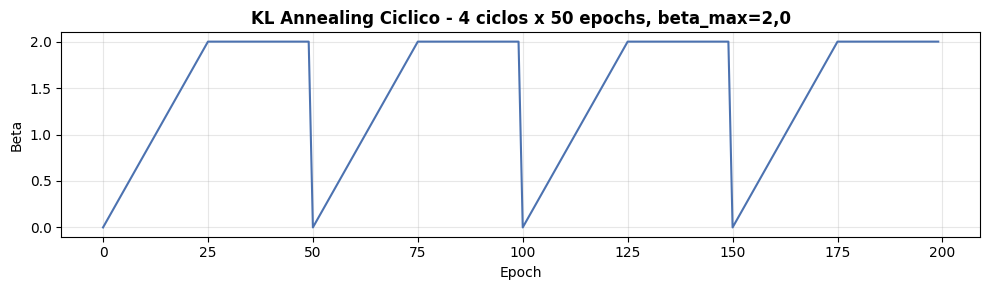

In [ ]:
LPH_CONT_INDICES = [cont_norm_cols.index(c + '_norm')
                     for c in ['ph_months_current_24', 'ph_months_delinquent_24',
                                'ph_max_delinquency_24']
                     if c + '_norm' in cont_norm_cols]
print(f"Indices LPH en continuas: {LPH_CONT_INDICES}")


def calcular_perdida_vae(recon_cont, recon_bin, recon_cats, x_cont, x_bin,
                         x_cat_dict, mu, logvar, lph_mask, beta, cat_names):
    """Perdida del beta-VAE: MSE + CE + BCE + beta * KL, con mascara LPH."""

    mse_per_feature = F.mse_loss(recon_cont, x_cont, reduction='none')

    # no penalizar reconstruccion LPH cuando no hay datos
    if len(LPH_CONT_INDICES) > 0:
        for idx in LPH_CONT_INDICES:
            mse_per_feature[:, idx] = mse_per_feature[:, idx] * lph_mask

    loss_cont = mse_per_feature.mean()
    loss_bin = F.binary_cross_entropy(recon_bin, x_bin, reduction='mean')

    loss_cat = 0.0
    for col in cat_names:
        loss_cat += F.cross_entropy(recon_cats[col], x_cat_dict[col],
                                    reduction='mean')

    kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()

    loss_recon = loss_cont + loss_bin + loss_cat
    loss_total = loss_recon + beta * kl

    return loss_total, {
        'total': loss_total.item(),
        'recon': loss_recon.item(),
        'cont': loss_cont.item(),
        'bin': loss_bin.item(),
        'cat': loss_cat if isinstance(loss_cat, float) else loss_cat.item(),
        'kl': kl.item(),
        'beta': beta,
    }


def beta_ciclico(epoch, cycle_len=50, max_beta=2.0, ratio=0.5):
    """KL annealing ciclico (Fu et al., 2019)."""
    tau = (epoch % cycle_len) / cycle_len
    if tau < ratio:
        return max_beta * (tau / ratio)
    return max_beta


betas = [beta_ciclico(e) for e in range(200)]
plt.figure(figsize=(10, 3))
plt.plot(betas, color='#4C72B0', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Beta')
plt.title('KL Annealing Ciclico - 4 ciclos x 50 epochs, beta_max=2,0',
          fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'kl_annealing_schedule.png', dpi=150,
            bbox_inches='tight')
plt.show()

## **Entrenamiento**

Hiperparametros del training loop:
- 200 epochs maximo con Early Stopping
- 20 epochs de paciencia para parar
- `ReduceLROnPlateau` con factor 0,5 y paciencia 10
- Gradient clipping con `max_norm=5,0`
- Checkpoints cada 50 epochs

In [ ]:
def entrenar_vae(z_dim, max_epochs=200, patience=20, cycle_len=50,
                 max_beta=2.0):
    """Entrena un TabularVAE con z_dim dado."""

    model = TabularVAE(N_CONT, N_BIN, CAT_CARDINALITIES, EMB_DIMS,
                       z_dim=z_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5
    )

    history = {'train': [], 'val': []}
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None
    epochs_no_improve = 0
    cat_names = list(CAT_CARDINALITIES.keys())

    print(f"\nEntrenando VAE con z_dim={z_dim} | "
          f"{max_epochs} epochs max | patience={patience}")
    print("-" * 60)

    t0 = time.time()

    for epoch in range(max_epochs):
        beta = beta_ciclico(epoch, cycle_len, max_beta)

        model.train()
        train_metrics = []
        for batch in train_loader:
            cont, bins, cats, lph = [x.to(DEVICE) for x in batch]
            cat_dict = {col: cats[:, i] for i, col in enumerate(cat_names)}

            recon_cont, recon_bin, recon_cats, mu, logvar, z = model(
                cont, bins, cat_dict)
            loss, metrics = calcular_perdida_vae(
                recon_cont, recon_bin, recon_cats, cont, bins, cat_dict,
                mu, logvar, lph, beta, cat_names)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_metrics.append(metrics)

        model.eval()
        val_metrics = []
        with torch.no_grad():
            for batch in val_loader:
                cont, bins, cats, lph = [x.to(DEVICE) for x in batch]
                cat_dict = {col: cats[:, i]
                            for i, col in enumerate(cat_names)}

                recon_cont, recon_bin, recon_cats, mu, logvar, z = model(
                    cont, bins, cat_dict)
                _, metrics = calcular_perdida_vae(
                    recon_cont, recon_bin, recon_cats, cont, bins, cat_dict,
                    mu, logvar, lph, beta, cat_names)
                val_metrics.append(metrics)

        train_avg = {k: np.mean([m[k] for m in train_metrics])
                     for k in train_metrics[0]}
        val_avg = {k: np.mean([m[k] for m in val_metrics])
                   for k in val_metrics[0]}
        history['train'].append(train_avg)
        history['val'].append(val_avg)

        scheduler.step(val_avg['total'])

        if val_avg['total'] < best_val_loss:
            best_val_loss = val_avg['total']
            best_epoch = epoch
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch % 10 == 0 or epoch == max_epochs - 1
                or epochs_no_improve == patience):
            elapsed = time.time() - t0
            lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:3d} | beta={beta:.2f} | "
                  f"train={train_avg['total']:.4f} | "
                  f"val={val_avg['total']:.4f} | "
                  f"KL={val_avg['kl']:.3f} | recon={val_avg['recon']:.4f} | "
                  f"lr={lr:.1e} | {elapsed:.0f}s")

        if (epoch + 1) % 50 == 0:
            ckpt_path = CHECKPOINT_DIR / f'vae_z{z_dim}_epoch{epoch+1}.pt'
            torch.save(model.state_dict(), ckpt_path)

        if epochs_no_improve >= patience:
            print(f"  -> Early stopping en epoch {epoch} (best: {best_epoch})")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)

    total_time = time.time() - t0
    print(f"  Completado en {total_time:.0f}s ({total_time/60:.1f} min)")
    print(f"  Mejor epoch: {best_epoch} | Mejor val_loss: {best_val_loss:.4f}")

    return model, history, best_epoch

## **Grid search sobre z**

Entrenamos 3 modelos con z en {8, 16, 32} y guardamos el mejor
checkpoint de cada uno para comparar despues.

In [ ]:
Z_CANDIDATES = [8, 16, 32]
grid_results = {}

for z_dim in Z_CANDIDATES:
    model, history, best_epoch = entrenar_vae(z_dim=z_dim)
    grid_results[z_dim] = {
        'model': model,
        'history': history,
        'best_epoch': best_epoch,
    }
    torch.save(model.state_dict(), CHECKPOINT_DIR / f'vae_z{z_dim}_best.pt')

print("\nResumen grid search:")
print(f"{'z_dim':>6} | {'best_epoch':>10} | {'val_loss':>10} | "
      f"{'KL':>8} | {'recon':>8}")
print("-" * 55)
for z, res in grid_results.items():
    val_last = res['history']['val'][res['best_epoch']]
    print(f"{z:>6} | {res['best_epoch']:>10} | {val_last['total']:>10.4f} | "
          f"{val_last['kl']:>8.3f} | {val_last['recon']:>8.4f}")


Entrenando VAE con z_dim=8 | 200 epochs max | patience=20
------------------------------------------------------------
  Epoch   0 | beta=0.00 | train=2.5820 | val=0.9206 | KL=60.682 | recon=0.9206 | lr=1.0e-03 | 19s
  Epoch  10 | beta=0.80 | train=7.4192 | val=6.9864 | KL=4.233 | recon=3.5999 | lr=1.0e-03 | 159s
  Epoch  20 | beta=1.60 | train=8.4966 | val=8.4244 | KL=0.571 | recon=7.5100 | lr=5.0e-04 | 296s
  -> Early stopping en epoch 20 (best: 0)
  Completado en 296s (4.9 min)
  Mejor epoch: 0 | Mejor val_loss: 0.9206

Entrenando VAE con z_dim=16 | 200 epochs max | patience=20
------------------------------------------------------------
  Epoch   0 | beta=0.00 | train=2.3635 | val=0.7647 | KL=85.781 | recon=0.7647 | lr=1.0e-03 | 14s
  Epoch  10 | beta=0.80 | train=7.4308 | val=6.9831 | KL=4.091 | recon=3.7102 | lr=1.0e-03 | 149s
  Epoch  20 | beta=1.60 | train=8.5043 | val=8.4152 | KL=0.587 | recon=7.4757 | lr=5.0e-04 | 287s
  -> Early stopping en epoch 20 (best: 0)
  Completado e

## **Diagnostico del espacio latente**

Verificamos cuantas dimensiones latentes son activas (AU > 0,01),
la calidad de reconstruccion, y las curvas de entrenamiento de
cada modelo del grid search.


Diagnostico z=8 (val):
  Unidades Activas (AU): 8/8 (umbral 0,01)
  Varianza por dim: [4.938 5.981 5.459 7.893 6.108 9.532 6.777 8.769]


/tmp/ipython-input-2059257815.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([all_mu[:, d] for d in range(min(z_dim, 16))],


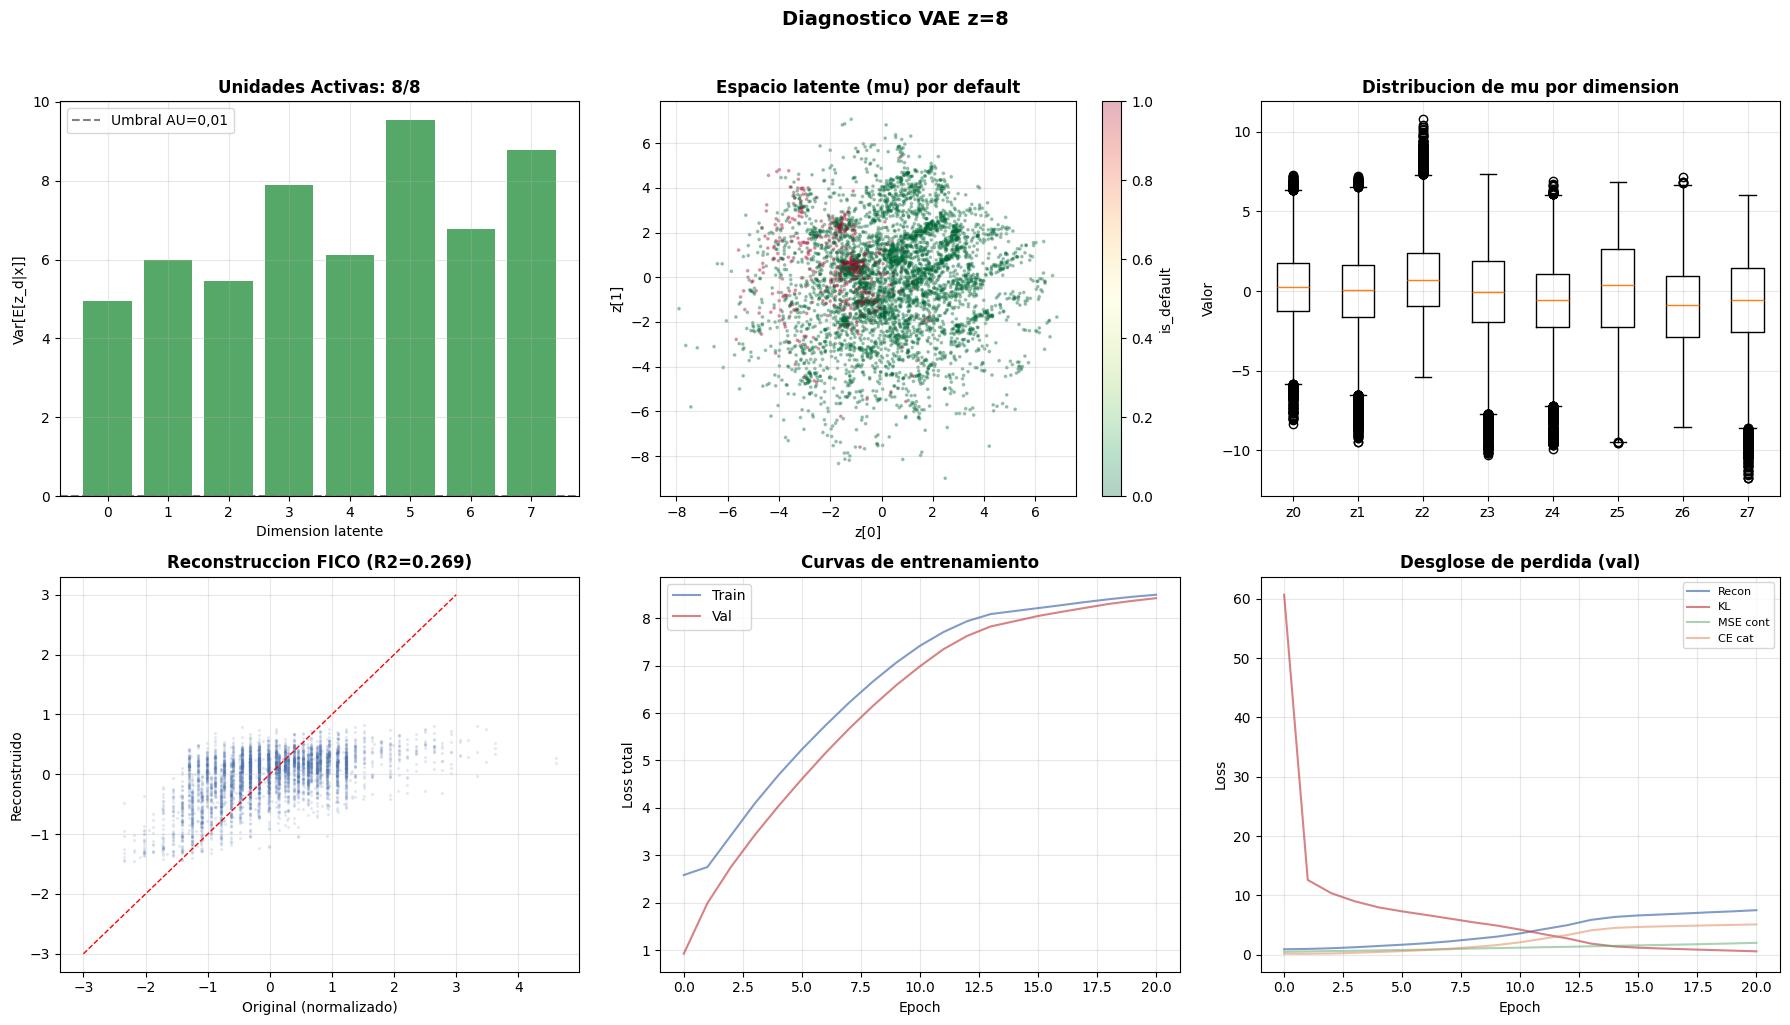


Diagnostico z=16 (val):
  Unidades Activas (AU): 16/16 (umbral 0,01)
  Varianza por dim: [3.634 3.8   3.099 2.493 4.21  5.847 2.632 5.777 5.142 3.827 5.528 2.928
 4.183 2.285 4.802 5.706]


/tmp/ipython-input-2059257815.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([all_mu[:, d] for d in range(min(z_dim, 16))],


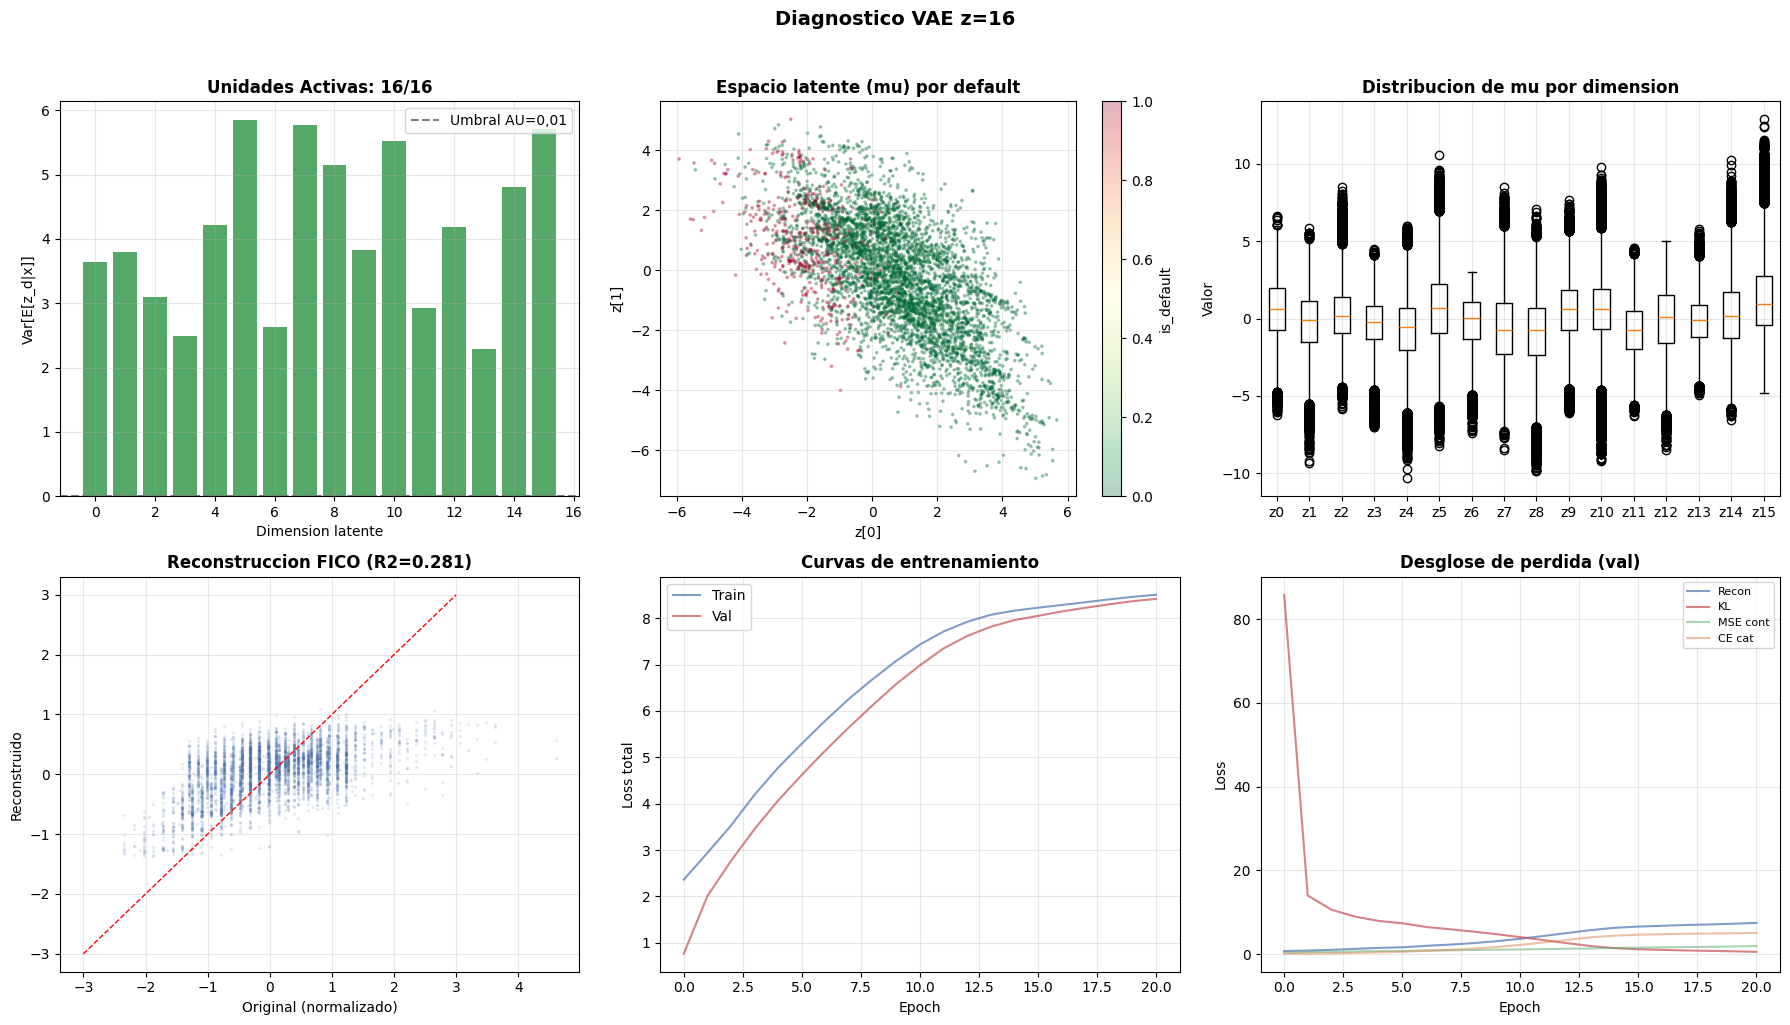


Diagnostico z=32 (val):
  Unidades Activas (AU): 32/32 (umbral 0,01)
  Varianza por dim: [4.122 3.773 2.043 2.322 2.689 2.635 4.537 1.956 3.714 2.42  2.788 5.147
 4.18  2.414 4.635 3.396 3.201 2.942 2.857 3.218 3.595 4.079 3.212 1.97
 2.119 2.928 3.135 3.004 2.66  2.479 3.682 1.896]


/tmp/ipython-input-2059257815.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([all_mu[:, d] for d in range(min(z_dim, 16))],


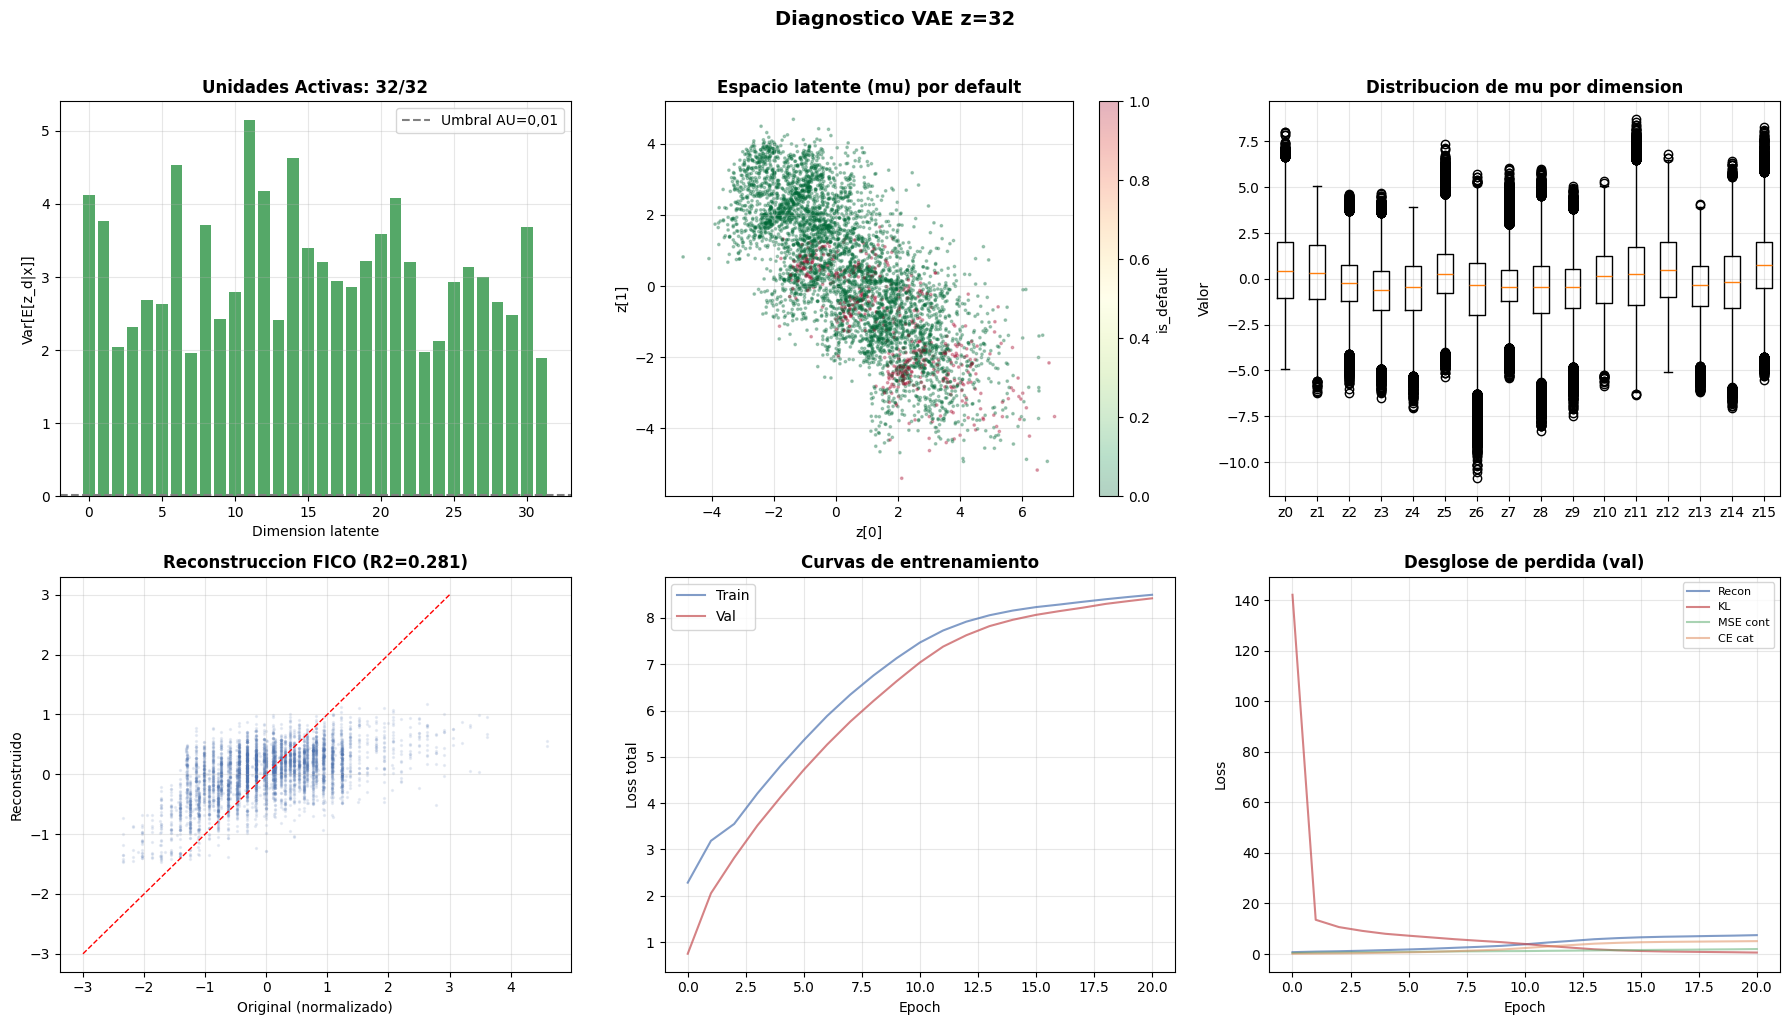

In [ ]:
def diagnosticar_vae(model, z_dim, loader, label='val'):
    """Diagnostico completo: AU, scatter, reconstruccion, curvas."""
    model.eval()
    cat_names = list(CAT_CARDINALITIES.keys())
    all_mu, all_z, all_cont, all_recon_cont = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            cont, bins, cats, lph = [x.to(DEVICE) for x in batch]
            cat_dict = {col: cats[:, i] for i, col in enumerate(cat_names)}
            recon_cont, _, _, mu, logvar, z = model(cont, bins, cat_dict)
            all_mu.append(mu.cpu())
            all_z.append(z.cpu())
            all_cont.append(cont.cpu())
            all_recon_cont.append(recon_cont.cpu())

    all_mu = torch.cat(all_mu, dim=0).numpy()
    all_z = torch.cat(all_z, dim=0).numpy()
    all_cont = torch.cat(all_cont, dim=0).numpy()
    all_recon_cont = torch.cat(all_recon_cont, dim=0).numpy()

    # Unidades Activas: Var[E[z_d|x]] > 0,01
    au_var = np.var(all_mu, axis=0)
    au_count = (au_var > 0.01).sum()
    print(f"\nDiagnostico z={z_dim} ({label}):")
    print(f"  Unidades Activas (AU): {au_count}/{z_dim} (umbral 0,01)")
    print(f"  Varianza por dim: {np.array2string(au_var, precision=3)}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # AU por dimension
    ax = axes[0, 0]
    colores_au = ['#55A868' if v > 0.01 else '#C44E52' for v in au_var]
    ax.bar(range(z_dim), au_var, color=colores_au)
    ax.axhline(0.01, color='gray', linestyle='--', label='Umbral AU=0,01')
    ax.set_xlabel('Dimension latente')
    ax.set_ylabel('Var[E[z_d|x]]')
    ax.set_title(f'Unidades Activas: {au_count}/{z_dim}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # scatter z[0] vs z[1] coloreado por default
    ax = axes[0, 1]
    is_default_val = df.iloc[val_idx]['is_default'].values[:len(all_mu)]
    scatter = ax.scatter(all_mu[:5000, 0], all_mu[:5000, 1],
                         c=is_default_val[:5000], cmap='RdYlGn_r',
                         alpha=0.3, s=3)
    ax.set_xlabel('z[0]')
    ax.set_ylabel('z[1]')
    ax.set_title('Espacio latente (mu) por default', fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='is_default')
    ax.grid(True, alpha=0.3)

    # boxplot de mu por dimension
    ax = axes[0, 2]
    ax.boxplot([all_mu[:, d] for d in range(min(z_dim, 16))],
               labels=[f'z{d}' for d in range(min(z_dim, 16))])
    ax.set_title('Distribucion de mu por dimension', fontweight='bold')
    ax.set_ylabel('Valor')
    ax.grid(True, alpha=0.3)

    # reconstruccion FICO (primera continua)
    ax = axes[1, 0]
    fico_idx = 0
    sample_n = min(5000, len(all_cont))
    ax.scatter(all_cont[:sample_n, fico_idx],
               all_recon_cont[:sample_n, fico_idx],
               alpha=0.1, s=2, color='#4C72B0')
    ax.plot([-3, 3], [-3, 3], 'r--', linewidth=1)
    r2 = np.corrcoef(all_cont[:, fico_idx],
                     all_recon_cont[:, fico_idx])[0, 1]**2
    ax.set_xlabel('Original (normalizado)')
    ax.set_ylabel('Reconstruido')
    ax.set_title(f'Reconstruccion FICO (R2={r2:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # curvas de loss
    ax = axes[1, 1]
    history = grid_results[z_dim]['history']
    epochs_range = range(len(history['train']))
    ax.plot(epochs_range, [m['total'] for m in history['train']],
            color='#4C72B0', label='Train', alpha=0.7)
    ax.plot(epochs_range, [m['total'] for m in history['val']],
            color='#C44E52', label='Val', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss total')
    ax.set_title('Curvas de entrenamiento', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # desglose de perdida (val)
    ax = axes[1, 2]
    ax.plot(epochs_range, [m['recon'] for m in history['val']],
            color='#4C72B0', label='Recon', alpha=0.7)
    ax.plot(epochs_range, [m['kl'] for m in history['val']],
            color='#C44E52', label='KL', alpha=0.7)
    ax.plot(epochs_range, [m['cont'] for m in history['val']],
            color='#55A868', label='MSE cont', alpha=0.5)
    ax.plot(epochs_range, [m['cat'] for m in history['val']],
            color='#DD8452', label='CE cat', alpha=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Desglose de perdida (val)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f'Diagnostico VAE z={z_dim}', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'diagnostico_vae_z{z_dim}.png', dpi=150,
                bbox_inches='tight')
    plt.show()

    return au_count, au_var


au_results = {}
for z_dim in Z_CANDIDATES:
    model = grid_results[z_dim]['model']
    au_count, au_var = diagnosticar_vae(model, z_dim, val_loader)
    au_results[z_dim] = au_count

## **Seleccion del mejor z**

Combinamos AU ratio, val_loss y silhouette preliminar (K-Means K=5)
para elegir la dimension latente optima.

In [ ]:
from sklearn.cluster import KMeans

sil_results = {}
cat_names = list(CAT_CARDINALITIES.keys())

for z_dim in Z_CANDIDATES:
    model = grid_results[z_dim]['model']
    model.eval()

    embeddings = []
    with torch.no_grad():
        for batch in val_loader:
            cont, bins, cats, lph = [x.to(DEVICE) for x in batch]
            cat_dict = {col: cats[:, i] for i, col in enumerate(cat_names)}
            mu, _ = model.encode(cont, bins, cat_dict)
            embeddings.append(mu.cpu().numpy())

    embeddings = np.concatenate(embeddings, axis=0)

    # silhouette con K=5 sobre subsample de 20k para velocidad
    km = KMeans(n_clusters=5, n_init=10, random_state=SEED)
    labels = km.fit_predict(embeddings[:20000])
    sil = silhouette_score(embeddings[:20000], labels)
    sil_results[z_dim] = sil

print("\nComparacion final:")
print(f"{'z_dim':>6} | {'AU':>5} | {'val_loss':>10} | {'silhouette':>11}")
print("-" * 45)
for z_dim in Z_CANDIDATES:
    val_loss = grid_results[z_dim]['history']['val'][
        grid_results[z_dim]['best_epoch']]['total']
    print(f"{z_dim:>6} | {au_results[z_dim]:>3}/{z_dim:<2} | "
          f"{val_loss:>10.4f} | {sil_results[z_dim]:>11.4f}")

# score compuesto: AU_ratio * (1 - val_loss_norm) * silhouette
val_losses = {z: grid_results[z]['history']['val'][
    grid_results[z]['best_epoch']]['total'] for z in Z_CANDIDATES}
max_vl = max(val_losses.values())
scores = {}
for z_dim in Z_CANDIDATES:
    au_ratio = au_results[z_dim] / z_dim
    vl_norm = 1 - val_losses[z_dim] / max_vl
    scores[z_dim] = au_ratio * (0.5 + vl_norm) * sil_results[z_dim]

BEST_Z = max(scores, key=scores.get)
print(f"\nMejor z_dim seleccionado: {BEST_Z}")
print(f"  AU: {au_results[BEST_Z]}/{BEST_Z} | "
      f"val_loss: {val_losses[BEST_Z]:.4f} | "
      f"silhouette: {sil_results[BEST_Z]:.4f}")

best_model = grid_results[BEST_Z]['model']


Comparacion final:
 z_dim |    AU |   val_loss |  silhouette
---------------------------------------------
     8 |   8/8  |     0.9206 |      0.1571
    16 |  16/16 |     0.7647 |      0.1438
    32 |  32/32 |     0.7489 |      0.1412

Mejor z_dim seleccionado: 32
  AU: 32/32 | val_loss: 0.7489 | silhouette: 0.1412


## **Proyeccion de embeddings**

Proyectamos el Subset B completo (500k) y el Subset A (50k) por el
encoder del mejor modelo. Subset A necesita las columnas extra de
Subset B rellenadas con valores por defecto.

In [ ]:
def proyectar_embeddings(model, df_input, device, batch_size=2048):
    """Proyecta un DataFrame preprocesado por el encoder del VAE."""
    model.eval()
    cat_names_local = list(CAT_CARDINALITIES.keys())

    cont = torch.tensor(df_input[cont_norm_cols].values, dtype=torch.float32)
    bins = torch.tensor(df_input[bin_cols].values, dtype=torch.float32)
    cats = torch.tensor(df_input[[c + '_enc' for c in CATEGORICAL_COLS]].values,
                        dtype=torch.long)

    embeddings = []
    n = len(cont)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        c = cont[start:end].to(device)
        b = bins[start:end].to(device)
        cat_batch = cats[start:end].to(device)
        cat_dict = {col: cat_batch[:, i]
                    for i, col in enumerate(cat_names_local)}

        with torch.no_grad():
            mu, _ = model.encode(c, b, cat_dict)
        embeddings.append(mu.cpu().numpy())

    return np.concatenate(embeddings, axis=0)


# Subset B completo (500k)
print("Proyectando Subset B (500k loans)...")
emb_500k = proyectar_embeddings(best_model, df, DEVICE)
print(f"  Shape: {emb_500k.shape}")

Proyectando Subset B (500k loans)...
  Shape: (498542, 32)


### *Preprocesamiento de Subset A*

Subset A tiene 41 cols vs 51 de Subset B. Las 10 columnas faltantes
se rellenan con medianas del Subset B o valores neutrales.

In [ ]:
df_a_proc = df_a.copy()

# columnas que solo existen en Subset B
SUBSET_B_ONLY_COLS = ['co_borrower_credit_score', 'mi_type', 'num_units',
                       'months_delinquent_60plus', 'had_servicing_transfer',
                       'ph_months_current_24', 'ph_recent_delinquency_3m',
                       'rate_spread', 'upb_paydown_pct', 'last_active_upb']

for col in SUBSET_B_ONLY_COLS:
    if col not in df_a_proc.columns:
        if col in CATEGORICAL_COLS:
            df_a_proc[col] = 'MISSING'
        elif col in BINARY_COLS:
            df_a_proc[col] = 0
        else:
            df_a_proc[col] = df[col].median() if col in df.columns else 0

# missing indicator
df_a_proc['co_borrower_fico_missing'] = (
    1 if 'co_borrower_credit_score' not in df_a.columns
    else df_a_proc['co_borrower_credit_score'].isnull().astype(int)
)

if 'co_borrower_credit_score' in df_a_proc.columns:
    df_a_proc['co_borrower_credit_score'] = (
        df_a_proc['co_borrower_credit_score'].fillna(co_median))

if 'time_to_first_delinquency' in df_a_proc.columns:
    df_a_proc['time_to_first_delinquency'] = (
        df_a_proc['time_to_first_delinquency'].fillna(
            df_a_proc['loan_duration_months']))

for col in lph_cols:
    if col in df_a_proc.columns:
        df_a_proc[col] = df_a_proc[col].fillna(0)

for col in ALL_CONTINUOUS:
    if col in df_a_proc.columns and df_a_proc[col].isnull().any():
        df_a_proc[col] = df_a_proc[col].fillna(df_a_proc[col].median())

for col, mapping in binary_string_map.items():
    if col in df_a_proc.columns and df_a_proc[col].dtype == object:
        df_a_proc[col] = df_a_proc[col].map(mapping).fillna(0).astype(int)
for col in BINARY_COLS:
    if col in df_a_proc.columns:
        df_a_proc[col] = df_a_proc[col].fillna(0).astype(int)

# label-encode con los mismos encoders del Subset B
for col in CATEGORICAL_COLS:
    le = label_encoders[col]
    vals = df_a_proc[col].fillna('MISSING').astype(str)
    known = set(le.classes_)
    # categorias no vistas -> fallback a la mas frecuente
    vals = vals.apply(lambda x: x if x in known else le.classes_[0])
    df_a_proc[col + '_enc'] = le.transform(vals)

# transformaciones continuas (mismos transformers del train)
for col in BIMODAL_COLS:
    if col in df_a_proc.columns:
        gmm = gmm_transformers[col]
        all_vals = df_a_proc[col].values.reshape(-1, 1)
        components = gmm.predict(all_vals)
        normalized = np.zeros(len(all_vals), dtype=np.float32)
        for comp in range(2):
            mask = components == comp
            if mask.sum() > 0:
                mu_c = gmm.means_[comp, 0]
                std_c = np.sqrt(gmm.covariances_[comp, 0, 0])
                normalized[mask] = (all_vals[mask, 0] - mu_c) / (std_c + 1e-8)
        df_a_proc[col + '_norm'] = normalized

for col in HEAVY_TAIL_COLS:
    if col in df_a_proc.columns:
        df_a_proc[col + '_log'] = np.log1p(df_a_proc[col].clip(lower=0))
        scaler = heavy_scalers[col]
        df_a_proc[col + '_norm'] = scaler.transform(
            df_a_proc[[col + '_log']]).flatten()
        df_a_proc.drop(columns=[col + '_log'], inplace=True)

for col in ZERO_INFLATED_COLS:
    if col in df_a_proc.columns:
        df_a_proc[col + '_nonzero'] = (df_a_proc[col] > 0).astype(int)
        qt = zi_qts[col]
        df_a_proc[col + '_norm'] = 0.0
        if qt is not None:
            nonzero_mask = df_a_proc[col] > 0
            if nonzero_mask.sum() > 0:
                df_a_proc.loc[nonzero_mask, col + '_norm'] = qt.transform(
                    df_a_proc.loc[nonzero_mask, [col]]).flatten()

# QT estandar: construir DataFrame completo en el orden original
df_std_full = pd.DataFrame(index=df_a_proc.index)
for c in STANDARD_CONT_COLS:
    df_std_full[c] = df_a_proc[c] if c in df_a_proc.columns else 0.0
transformed = qt_standard.transform(df_std_full)
for i, c in enumerate(STANDARD_CONT_COLS):
    df_a_proc[c + '_norm'] = transformed[:, i]

# asegurar que todas las columnas necesarias existen
for col in cont_norm_cols + [c + '_enc' for c in CATEGORICAL_COLS] + bin_cols:
    if col not in df_a_proc.columns:
        df_a_proc[col] = 0

print("Proyectando Subset A (50k loans)...")
emb_50k = proyectar_embeddings(best_model, df_a_proc, DEVICE)
print(f"  Shape: {emb_50k.shape}")

# guardar embeddings
emb_cols = [f'z{i}' for i in range(BEST_Z)]

df_emb_50k = pd.DataFrame(emb_50k, columns=emb_cols)
df_emb_50k.insert(0, 'loan_id', df_a['loan_id'].values)
df_emb_50k.to_csv(RESULTS_DIR / 'vae_embeddings_50k.csv', index=False)
print(f"\nGuardado: vae_embeddings_50k.csv ({df_emb_50k.shape})")

np.savez_compressed(RESULTS_DIR / 'vae_embeddings_500k.npz',
                     embeddings=emb_500k,
                     loan_ids=df['loan_id'].values)
print(f"Guardado: vae_embeddings_500k.npz ({emb_500k.shape})")

Proyectando Subset A (50k loans)...
  Shape: (49735, 32)

Guardado: vae_embeddings_50k.csv ((49735, 33))
Guardado: vae_embeddings_500k.npz ((498542, 32))


## **Visualizacion exploratoria**

t-SNE y UMAP sobre los embeddings del Subset A coloreados por
`is_default`, `stratum` y `vintage_bin`.

In [ ]:
from sklearn.manifold import TSNE

n_tsne = min(10000, len(emb_50k))
idx_tsne = np.random.choice(len(emb_50k), n_tsne, replace=False)
emb_sample = emb_50k[idx_tsne]

print("Calculando t-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_tsne = tsne.fit_transform(emb_sample)

try:
    import umap
except ImportError:
    print("Instalando umap-learn...")
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'umap-learn', '-q'])
    import umap

print("Calculando UMAP...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                     random_state=SEED)
X_umap = reducer.fit_transform(emb_sample)

Calculando t-SNE...
Calculando UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


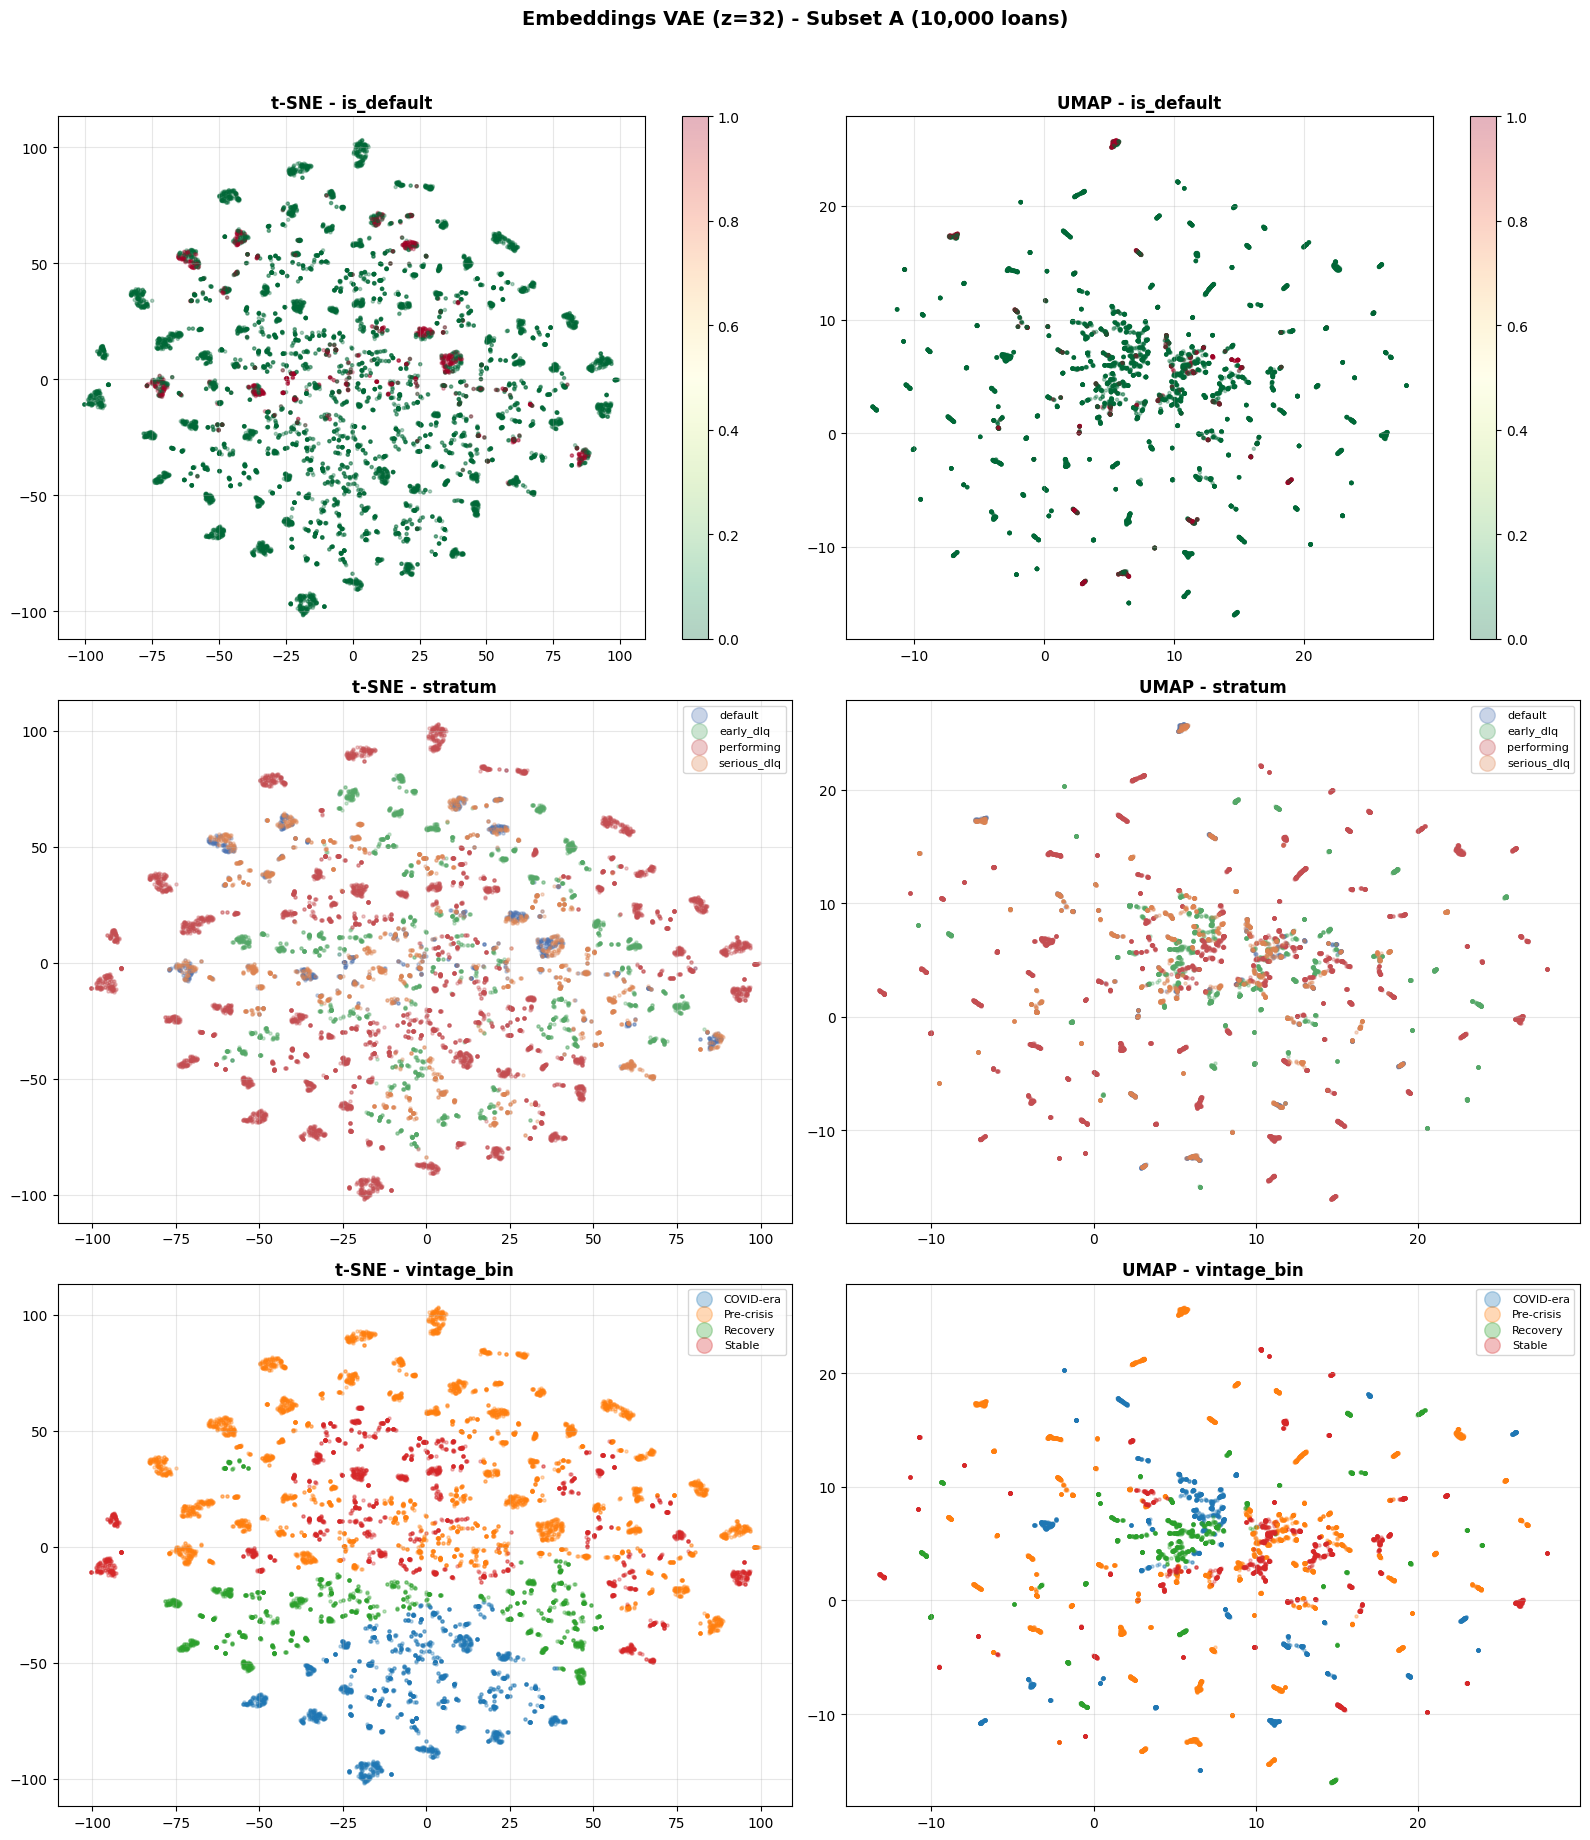

In [ ]:
is_default_sample = df_a.iloc[idx_tsne]['is_default'].values
stratum_sample = df_a.iloc[idx_tsne]['stratum'].values
vintage_sample = (df_a.iloc[idx_tsne]['vintage_bin'].values
                  if 'vintage_bin' in df_a.columns else None)

fig, axes_grid = plt.subplots(3, 2, figsize=(16, 18))

projections = [('t-SNE', X_tsne), ('UMAP', X_umap)]

for col_idx, (name, coords) in enumerate(projections):
    # por is_default
    ax = axes_grid[0, col_idx]
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=is_default_sample,
                         cmap='RdYlGn_r', alpha=0.3, s=5)
    ax.set_title(f'{name} - is_default', fontweight='bold')
    plt.colorbar(scatter, ax=ax)
    ax.grid(True, alpha=0.3)

    # por stratum
    ax = axes_grid[1, col_idx]
    strata_unique = np.unique(stratum_sample)
    colores_strata = ['#4C72B0', '#55A868', '#C44E52', '#DD8452',
                      '#8172B3', '#937860']
    for i, s in enumerate(strata_unique):
        mask = stratum_sample == s
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   label=s, alpha=0.3, s=5,
                   color=colores_strata[i % len(colores_strata)])
    ax.set_title(f'{name} - stratum', fontweight='bold')
    ax.legend(markerscale=5, fontsize=8)
    ax.grid(True, alpha=0.3)

    # por vintage_bin
    ax = axes_grid[2, col_idx]
    if vintage_sample is not None:
        for v in np.unique(vintage_sample):
            mask = vintage_sample == v
            ax.scatter(coords[mask, 0], coords[mask, 1],
                       label=v, alpha=0.3, s=5)
        ax.set_title(f'{name} - vintage_bin', fontweight='bold')
        ax.legend(markerscale=5, fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

fig.suptitle(f'Embeddings VAE (z={BEST_Z}) - Subset A ({n_tsne:,} loans)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f'tsne_umap_embeddings_z{BEST_Z}.png', dpi=150,
            bbox_inches='tight')
plt.show()

## **Exportacion de artefactos y resumen**

In [ ]:
# modelo final
model_path = RESULTS_DIR / f'vae_model_z{BEST_Z}_best.pt'
torch.save({
    'model_state_dict': best_model.state_dict(),
    'z_dim': BEST_Z,
    'n_cont': N_CONT,
    'n_bin': N_BIN,
    'cat_cardinalities': CAT_CARDINALITIES,
    'emb_dims': EMB_DIMS,
    'best_epoch': grid_results[BEST_Z]['best_epoch'],
    'val_loss': grid_results[BEST_Z]['history']['val'][
        grid_results[BEST_Z]['best_epoch']]['total'],
}, model_path)
print(f"Modelo guardado: {model_path}")

# preprocessing artifacts para reproducir las transformaciones
artifacts = {
    'qt_standard': qt_standard,
    'label_encoders': label_encoders,
    'gmm_transformers': gmm_transformers,
    'heavy_scalers': heavy_scalers,
    'zi_qts': zi_qts,
    'co_borrower_median': co_median,
    'cont_norm_cols': cont_norm_cols,
    'bin_cols': bin_cols,
    'cat_enc_cols': [c + '_enc' for c in CATEGORICAL_COLS],
    'categorical_cols': CATEGORICAL_COLS,
    'cat_cardinalities': CAT_CARDINALITIES,
    'emb_dims': EMB_DIMS,
    'best_z': BEST_Z,
}
artifacts_path = RESULTS_DIR / 'preprocessing_artifacts.pkl'
with open(artifacts_path, 'wb') as f:
    pickle.dump(artifacts, f)
print(f"Artifacts guardados: {artifacts_path}")

# training log completo
log_data = []
for z_dim in Z_CANDIDATES:
    history = grid_results[z_dim]['history']
    for epoch, (t, v) in enumerate(zip(history['train'], history['val'])):
        log_data.append({
            'z_dim': z_dim,
            'epoch': epoch,
            'train_total': t['total'],
            'train_recon': t['recon'],
            'train_kl': t['kl'],
            'train_cont': t['cont'],
            'train_bin': t['bin'],
            'train_cat': t['cat'],
            'train_beta': t['beta'],
            'val_total': v['total'],
            'val_recon': v['recon'],
            'val_kl': v['kl'],
            'val_cont': v['cont'],
            'val_bin': v['bin'],
            'val_cat': v['cat'],
        })
df_log = pd.DataFrame(log_data)
log_path = RESULTS_DIR / 'vae_training_log.csv'
df_log.to_csv(log_path, index=False)
print(f"Training log guardado: {log_path}")

# resumen
print(f"\nResumen Fase III VAE:")
print(f"  Modelo: TabularVAE (MLP beta-VAE)")
print(f"  Mejor z_dim: {BEST_Z}")
print(f"  Input: {N_CONT} cont + {N_BIN} bin + {TOTAL_EMB_DIM} emb "
      f"= {INPUT_DIM} dims")
print(f"  AU: {au_results[BEST_Z]}/{BEST_Z}")
best_val = grid_results[BEST_Z]['history']['val'][
    grid_results[BEST_Z]['best_epoch']]['total']
print(f"  Val loss: {best_val:.4f}")
print(f"  Silhouette (K=5): {sil_results[BEST_Z]:.4f}")
print(f"  Best epoch: {grid_results[BEST_Z]['best_epoch']}")
print(f"\nArchivos generados:")
print(f"  {model_path}")
print(f"  {artifacts_path}")
print(f"  {RESULTS_DIR / 'vae_embeddings_50k.csv'}")
print(f"  {RESULTS_DIR / 'vae_embeddings_500k.npz'}")
print(f"  {log_path}")
print(f"\nSiguiente paso: Fase IV - Clustering")
print(f"  Cargar vae_embeddings_50k.csv + factor_scores.csv")
print(f"  Concatenar, normalizar, K-Means + GMM, validacion financiera")

Modelo guardado: /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/vae_model_z32_best.pt
Artifacts guardados: /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/preprocessing_artifacts.pkl
Training log guardado: /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/vae_training_log.csv

Resumen Fase III VAE:
  Modelo: TabularVAE (MLP beta-VAE)
  Mejor z_dim: 32
  Input: 21 cont + 11 bin + 15 emb = 47 dims
  AU: 32/32
  Val loss: 0.7489
  Silhouette (K=5): 0.1412
  Best epoch: 0

Archivos generados:
  /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/vae_model_z32_best.pt
  /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/preprocessing_artifacts.pkl
  /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/vae_embeddings_50k.csv
  /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/vae_embeddings_500k.npz
  /content/drive/MyDrive/Semestre 7/Analítica/proyecto-1/results/vae/